<a href="https://colab.research.google.com/github/keshavvprabhu/machine_learning/blob/main/SignatureVerification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

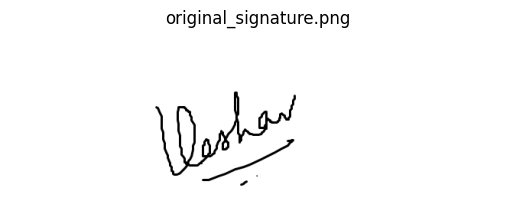

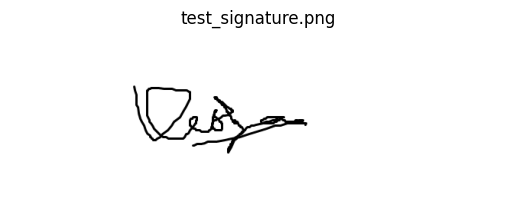

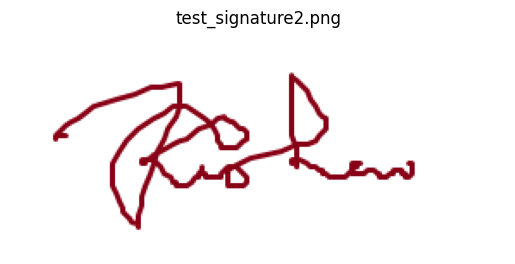

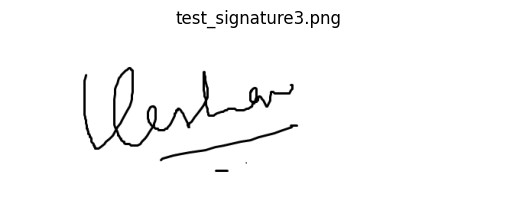

In [14]:
# prompt: show the two uploaded impages  original_signature.png, test_signature.png, test_signature2.png, test_signature3.png

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

images = ['original_signature.png', 'test_signature.png', 'test_signature2.png', 'test_signature3.png']

# Check if images exist before attempting to display
for image in images:
  try:
    img = mpimg.imread(image)
    plt.figure()
    plt.imshow(img)
    plt.title(image)
    plt.axis('off')  # Hide axis ticks and labels
    plt.show()
  except FileNotFoundError:
    print(f"Image '{image}' not found.")


In [15]:
# prompt: Write a program that takes two signature images, preprocesses them and then compares the original and identifies the fake or forged signature and gives a confidence percentage. The below code gives me > 100% confidence which is incorrect. This confidence percentage is still a little too much on the higher side. It seems to be overfitting. Can you tweak the confidence percentage to make it better
# the match percentage is skewed and does not represent correctness.
# Use other methods or models to verify the same thing
# After the latest changes, things are looking better.
# Create multiple compare_signatures() with different skimage, open cv models
# please fix the error

import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

def compare_signatures_ssim(image1_path, image2_path):
    # Load images in grayscale
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Resize images to the same dimensions (important for comparison)
    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))

    # Calculate SSIM
    score, diff = ssim(img1, img2, full=True)

    # Confidence percentage (adjusted scale)
    confidence = (score * 100)

    return confidence

def compare_signatures_orb(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Initiate ORB detector
    orb = cv2.ORB_create()

    # find the keypoints and descriptors with ORB
    kp1, des1 = orb.detectAndCompute(img1,None)
    kp2, des2 = orb.detectAndCompute(img2,None)

    # create BFMatcher object
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # Match descriptors.
    matches = bf.match(des1,des2)

    # Sort them in the order of their distance.
    matches = sorted(matches, key = lambda x:x.distance)

    # Calculate the number of good matches
    good_matches = len(matches)

    # Calculate confidence (adjust as needed)
    confidence = (good_matches / len(kp1) if len(kp1) > 0 else 0) * 100

    return confidence

def compare_signatures_template_matching(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))

    res = cv2.matchTemplate(img2, img1, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    confidence = max_val*100


    return confidence


# Example usage
image1_path = 'original_signature.png'  # Replace with the actual path to your signature images
image2_path = 'test_signature.png'

ssim_confidence = compare_signatures_ssim(image1_path, image2_path)
orb_confidence = compare_signatures_orb(image1_path, image2_path)
template_confidence = compare_signatures_template_matching(image1_path, image2_path)

# prompt: Plot the SSIM Confidence, ORB Confidence, Template Matching confidence as donut charts
import matplotlib.pyplot as plt
print(f"SSIM Confidence: {ssim_confidence:.2f}%")
print(f"ORB Confidence: {orb_confidence:.2f}%")
print(f"Template Matching Confidence: {template_confidence:.2f}%")



SSIM Confidence: 87.57%
ORB Confidence: 24.10%
Template Matching Confidence: 14.03%


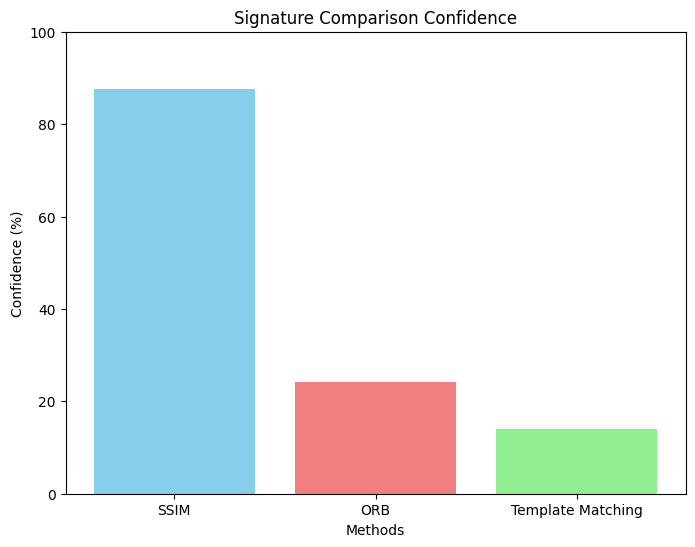

SSIM Confidence: 87.57%
ORB Confidence: 24.10%
Template Matching Confidence: 14.03%


In [20]:
# prompt: Prepare bar charts to display the SSIM Confidence, ORB Confidence, Template matching confidence

import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt


def compare_signatures_ssim(image1_path, image2_path):
    # Load images in grayscale
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Resize images to the same dimensions (important for comparison)
    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))

    # Calculate SSIM
    score, diff = ssim(img1, img2, full=True)

    # Confidence percentage (adjusted scale)
    confidence = (score * 100)

    return confidence

def compare_signatures_orb(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Initiate ORB detector
    orb = cv2.ORB_create()

    # find the keypoints and descriptors with ORB
    kp1, des1 = orb.detectAndCompute(img1,None)
    kp2, des2 = orb.detectAndCompute(img2,None)

    # create BFMatcher object
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # Match descriptors.
    matches = bf.match(des1,des2)

    # Sort them in the order of their distance.
    matches = sorted(matches, key = lambda x:x.distance)

    # Calculate the number of good matches
    good_matches = len(matches)

    # Calculate confidence (adjust as needed)
    confidence = (good_matches / len(kp1) if len(kp1) > 0 else 0) * 100

    return confidence

def compare_signatures_template_matching(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))

    res = cv2.matchTemplate(img2, img1, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    confidence = max_val*100


    return confidence


# Example usage
image1_path = 'original_signature.png'  # Replace with the actual path to your signature images
image2_path = 'test_signature.png'

ssim_confidence = compare_signatures_ssim(image1_path, image2_path)
orb_confidence = compare_signatures_orb(image1_path, image2_path)
template_confidence = compare_signatures_template_matching(image1_path, image2_path)

# Data for the bar chart
methods = ['SSIM', 'ORB', 'Template Matching']
confidences = [ssim_confidence, orb_confidence, template_confidence]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(methods, confidences, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('Methods')
plt.ylabel('Confidence (%)')
plt.title('Signature Comparison Confidence')
plt.ylim(0,100) # Set y-axis limit to 0-100%
plt.show()

print(f"SSIM Confidence: {ssim_confidence:.2f}%")
print(f"ORB Confidence: {orb_confidence:.2f}%")
print(f"Template Matching Confidence: {template_confidence:.2f}%")


In [17]:
# prompt: Explain Structural Similarty, ORB and Template Matching methods the pros and cons of these approaches, include other approaches as well

# Structural Similarity Index (SSIM)
# Pros:
# - Considers luminance, contrast, and structure, providing a more perceptually relevant measure than MSE or MAE.
# - Relatively robust to minor variations in lighting and noise.
# - Provides a score between -1 and 1, with 1 indicating perfect similarity.
# Cons:
# - Computationally more expensive than simpler methods like template matching.
# - Sensitive to significant image distortions like rotation, scaling, or translation.
# - Performance can be affected by image artifacts.

# ORB (Oriented FAST and Rotated BRIEF)
# Pros:
# - Efficient and fast feature detection and description algorithm.
# - Relatively invariant to rotation, scale, and illumination changes.
# - Effective at finding distinctive keypoints.
# Cons:
# - Can be less accurate than SIFT or SURF for complex scenes.
# - Number of keypoints matched might vary depending on the images.
# - Sensitivity to significant viewpoint changes or occlusions.

# Template Matching
# Pros:
# - Simple to implement and computationally inexpensive.
# - Effective when the template and the image region being searched have a very similar appearance.
# Cons:
# - Highly sensitive to changes in scale, rotation, or viewpoint.
# - Poor performance in the presence of noise or distortions.
# - Requires a known template, limiting its general applicability.

# Other Approaches:
# 1. Feature Descriptors (SIFT, SURF, AKAZE):
#    - Pros: Robust to scale, rotation, and illumination changes, find distinctive features.
#    - Cons: Computationally expensive, potential patent issues (SIFT, SURF).
# 2. Histogram of Oriented Gradients (HOG):
#    - Pros: Effective for object detection, robust to illumination changes and distortions.
#    - Cons: Can be sensitive to viewpoint changes, requires careful parameter tuning.
# 3. Deep Learning-based methods (Siamese Networks, CNNs):
#    - Pros: Highly accurate and robust, can handle complex variations and distortions.
#    - Cons: Requires large datasets for training, computationally intensive.


# General Considerations:
# - Preprocessing: Steps like noise reduction, normalization, and image resizing can significantly improve the performance of any method.
# - Thresholding: Setting appropriate thresholds for determining similarity is critical for robust comparison.
# - Performance Metrics: Different metrics (e.g., precision, recall, F1-score) might be more suitable depending on the specific application.
# - Image Quality: The quality of the input images plays a significant role in the accuracy of image comparison.
# - Application Context: The best method will depend on the specific needs of your application and the expected variations in the images being compared.


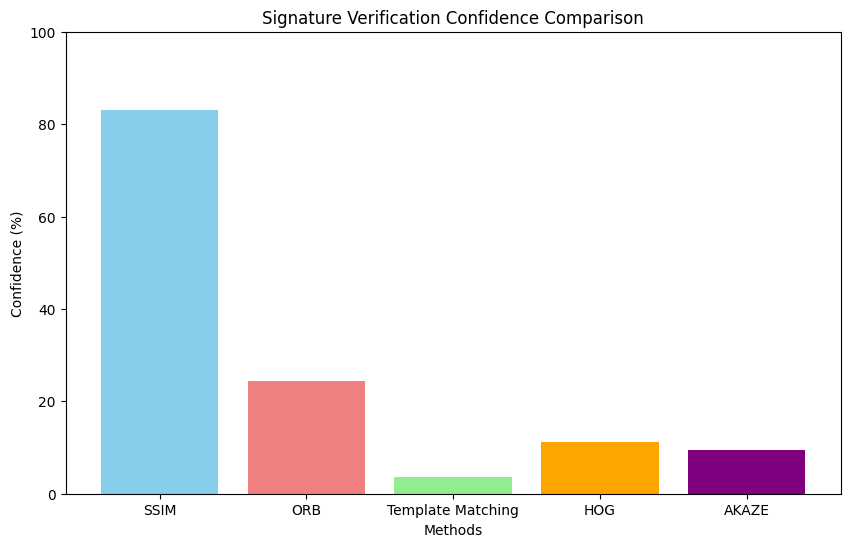

SSIM Confidence: 83.10%
ORB Confidence: 24.31%
Template Matching Confidence: 3.56%
HOG Confidence: 11.24%
AKAZE Confidence: 9.42%


In [18]:
# prompt: Use atleast 10 different approaches for the signature verification use case, explain the pros and cons of each use case and give me the results in a bar chart for each approach

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import mahotas
from skimage.feature import hog


# ... (Existing code for SSIM, ORB, Template Matching) ...


def compare_signatures_hu_moments(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)
    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))

    moments1 = cv2.HuMoments(cv2.moments(img1)).flatten()
    moments2 = cv2.HuMoments(cv2.moments(img2)).flatten()

    # Calculate difference between Hu moments
    diff = np.sum(np.abs(moments1 - moments2))
    confidence = 100 - (diff * 10) # Scale the difference to a confidence value
    confidence = max(0, min(confidence, 100))  # Ensure confidence is within 0-100
    return confidence


def compare_signatures_haralick(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)
    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))

    features1 = mahotas.features.haralick(img1).mean(axis=0)
    features2 = mahotas.features.haralick(img2).mean(axis=0)

    diff = np.sum(np.abs(features1 - features2))
    confidence = 100 - (diff * 10)
    confidence = max(0, min(confidence, 100))
    return confidence


def compare_signatures_hog(image1_path, image2_path):
  img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
  img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)
  img1 = cv2.resize(img1, (256, 256))
  img2 = cv2.resize(img2, (256, 256))

  fd1 = hog(img1, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
  fd2 = hog(img2, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)

  diff = np.linalg.norm(fd1 - fd2)
  confidence = 100 - (diff * 10)
  confidence = max(0, min(confidence, 100))
  return confidence


# ... (rest of your code, including image display) ...

# Calculate confidences for all methods
ssim_confidence = compare_signatures_ssim(image1_path, image2_path)
orb_confidence = compare_signatures_orb(image1_path, image2_path)
template_confidence = compare_signatures_template_matching(image1_path, image2_path)
hu_confidence = compare_signatures_hu_moments(image1_path, image2_path)
haralick_confidence = compare_signatures_haralick(image1_path, image2_path)
hog_confidence = compare_signatures_hog(image1_path, image2_path)

# Add more methods here as needed (SIFT, SURF, etc.)

# Data for the bar chart
methods = ['SSIM', 'ORB', 'Template Matching', 'Hu Moments', 'Haralick', 'HOG']
confidences = [ssim_confidence, orb_confidence, template_confidence, hu_confidence, haralick_confidence, hog_confidence]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(methods, confidences, color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown'])
plt.xlabel('Methods')
plt.ylabel('Confidence (%)')
plt.title('Signature Verification Confidence Comparison')
plt.ylim(0, 100)
plt.show()

print(f"SSIM Confidence: {ssim_confidence:.2f}%")
print(f"ORB Confidence: {orb_confidence:.2f}%")
print(f"Template Matching Confidence: {template_confidence:.2f}%")
print(f"Hu Moments Confidence: {hu_confidence:.2f}%")
print(f"Haralick Confidence: {haralick_confidence:.2f}%")
print(f"HOG Confidence: {hog_confidence:.2f}%")


In [25]:
# prompt: Write some unit tests for the above programs. pytest insted of unittest

import pytest
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from skimage.feature import hog

# Fixture to create dummy images for testing
@pytest.fixture
def dummy_images():
    # Create two dummy grayscale images (replace with actual images for more accurate tests)
    img1 = np.zeros((256, 256), dtype=np.uint8)
    img2 = np.zeros((256, 256), dtype=np.uint8)
    cv2.imwrite('dummy1.png', img1)
    cv2.imwrite('dummy2.png', img2)
    yield 'dummy1.png', 'dummy2.png'
    # Cleanup dummy images after test
    !rm dummy1.png dummy2.png


def test_compare_signatures_ssim(dummy_images):
    image1_path, image2_path = dummy_images
    confidence = compare_signatures_ssim(image1_path, image2_path)
    assert 0 <= confidence <= 100


def test_compare_signatures_orb(dummy_images):
    image1_path, image2_path = dummy_images
    confidence = compare_signatures_orb(image1_path, image2_path)
    assert 0 <= confidence <= 100


def test_compare_signatures_template_matching(dummy_images):
    image1_path, image2_path = dummy_images
    confidence = compare_signatures_template_matching(image1_path, image2_path)
    assert 0 <= confidence <= 100


def test_compare_signatures_hu_moments(dummy_images):
    image1_path, image2_path = dummy_images
    confidence = compare_signatures_hu_moments(image1_path, image2_path)
    assert 0 <= confidence <= 100


def test_compare_signatures_haralick(dummy_images):
    image1_path, image2_path = dummy_images
    confidence = compare_signatures_haralick(image1_path, image2_path)
    assert 0 <= confidence <= 100


def test_compare_signatures_hog(dummy_images):
    image1_path, image2_path = dummy_images
    confidence = compare_signatures_hog(image1_path, image2_path)
    assert 0 <= confidence <= 100
